# Forward Modeling Gravity
Gravity Method Tutorial #1

<b> Dicky Ahmad Zaky </b>
<br> Geophysical Engineering Department
<br> Universitas Pertamina

#### Introduction

The objective of this tutorial is to do forward modeling of simple model (sphere) gravity anomaly using python. 
First, Let's see the Ilustration below. 

<img src='https://chi01pap002files.storage.live.com/y4mURHMmBLOMfc-cDL71ye92M2phh_Uigy6fvUit16lJFbFCvnHbokehBinyUAKPC3UDbCR_ONrHB83XWr3gnHa-PpzmyKqWuIw_5tr0seo5dL1OcxczxWarfhCGLDq3CG7vtFXCgNNyc6Sh_wks6xwKaR6BbRaRGCioj5Gne0-jJLQdFh3rAOrSfVoHP9v33p0?width=660&height=258&cropmode=none'/>

The figure shows the buried sphere model with contras density $\Delta \rho$. The gravitational acceleration anomaly at observation point $P$ caused by the sphere is $\Delta g_r$, so the vertical component will be $\Delta g$. We can compute the $\Delta g$ by using this equation


\begin{align*}
\Delta g = \frac{G z \Delta \rho V}{(x^2+z^2)^{3/2}}
\end{align*}


To obtained gravitational acceleration anomaly over a the buried sphere we could use the equation above and varying the distances $x$. 


#### Define the parameter of sphere

Contras Density, $\Delta \rho = 250$ $kg/m^3$; 
<br> Radius of Sphere, $R = 50$ $m$; 
<br> Depth of the buried sphere, $Z = 100$ $m$; 

In [1]:
rho = 250
r = 50
z = 100

Calculate the volume of sphere

In [2]:
import numpy as np
v = 4 / 3 * np.pi * r**3

#### Define the parameter of profile line

Length of the line, $L = 1000$ $m$
<br> Space of the station, $dL = 10$ $m$
<br> Location of the sphere, $s = 500$ $m$

In [3]:
L = 1000
dL = 10
s = 500

#### Forward Modeling

By using the equation above, we will calculate every $\Delta g$ at every station. For the calculation, we will using vectorization rather than iteration.

In [4]:
G = 6.673 * 1e-11 # Gravitational Constant
dx = np.arange(0, L, dL) # Matrix of station location
x = dx - s # Horizontal distance of station to sphere

m = x**2 + z**2
n = m ** 1.5
g = G * rho * v *z / n * 1e5 # m/s^2 -> mGal 


#### Plotting the Anomaly

Using function plot to produce the anomaly profile

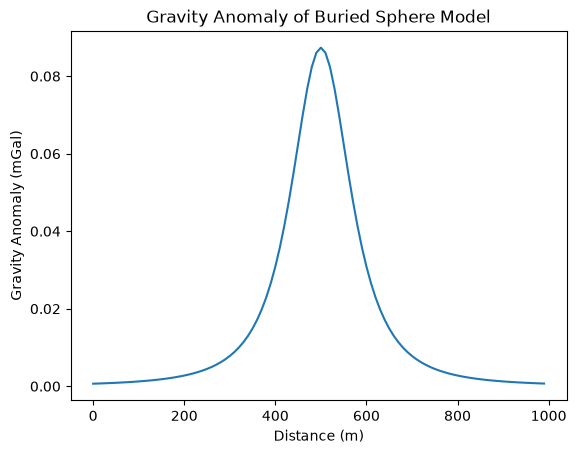

In [6]:
import matplotlib.pyplot as plt

plt.plot(dx, g, '-')
plt.title('Gravity Anomaly of Buried Sphere Model')
plt.ylabel('Gravity Anomaly (mGal)')
plt.xlabel('Distance (m)')
plt.show()


We could also produce the sphere model figure and arrange it below the anomaly profile

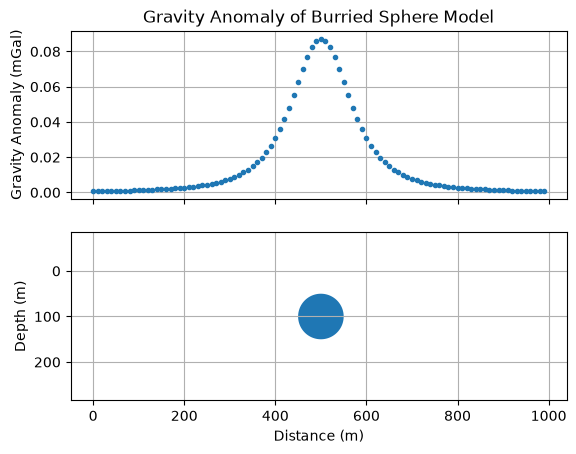

In [9]:
p = np.arange(0, 360, 1)  # angle in degree
q = np.array(p * np.pi / 180)  # angle in radian

fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True)
ax1.plot(dx, g, ".")
ax1.grid()
ax1.set_ylabel("Gravity Anomaly (mGal)")
ax1.set_title("Gravity Anomaly of Burried Sphere Model")

ax2.fill(r * np.cos(q) + s, r * np.sin(q) + z, "-")
ax2.axis('equal')
ax2.invert_yaxis()
ax2.grid()
ax2.set_xlabel("Distance (m)")
ax2.set_ylabel("Depth (m)")

plt.show()

#### Exercise

Let's playing around with the model
1. Varying the value of contrass density: try negative value, increasing and decrasing the value.
2. Varying the depth of the buried sphere: make itu shallower and deeper.
3. Varying the location of the sphere.
4. Varying the space of the station.
5. How about adding new sphere with the differnt contrass density?